In [33]:
import cv2
import numpy as np
from PIL import Image

def preprocess_for_lines(pil_img):
    img = np.array(pil_img)

    # If image is already grayscale (1 channel)
    if len(img.shape) == 2:
        gray = img
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Adaptive threshold (safe to apply again)
    thresh = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        25,
        15
    )

    return img, thresh



In [2]:
def connect_text_horizontally(thresh):
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (50, 1)
    )
    dilated = cv2.dilate(thresh, kernel, iterations=1)
    return dilated


In [28]:

def split_into_lines(pil_img):
    img, thresh = preprocess_for_lines(pil_img)
    dilated = connect_text_horizontally(thresh)

    projection = np.sum(dilated, axis=1)

    lines = []
    start = None

    for i, val in enumerate(projection):
        if val > 0 and start is None:
            start = i
        elif val == 0 and start is not None:
            if i - start > 20:   # minimum line height
                lines.append(Image.fromarray(img[start:i, :]))
            start = None

    if start is not None:
        lines.append(Image.fromarray(img[start:, :]))

    return lines

In [50]:
import numpy as np
from PIL import Image

def split_bw_image_into_valid_lines(
    bw_image,
    min_height=12,
    min_black_ratio=0.01
):
    img = np.array(bw_image)

    # Ensure grayscale
    if len(img.shape) == 3:
        img = img[:, :, 0]

    h, w = img.shape

    # Row contains text if black pixel exists
    row_has_text = np.any(img < 255, axis=1)

    lines = []
    start = None

    for i, has_text in enumerate(row_has_text):
        if has_text and start is None:
            start = i
        elif not has_text and start is not None:
            line = img[start:i, :]

            # ---- FILTERS ----
            height = i - start
            black_pixels = np.sum(line < 255)
            black_ratio = black_pixels / (line.size)

            if height >= min_height and black_ratio >= min_black_ratio:
                lines.append(Image.fromarray(line))

            start = None

    # Last line
    if start is not None:
        line = img[start:h, :]
        height = h - start
        black_pixels = np.sum(line < 255)
        black_ratio = black_pixels / (line.size)

        if height >= min_height and black_ratio >= min_black_ratio:
            lines.append(Image.fromarray(line))

    return lines


In [57]:
def convert_image_to_black_and_white(image):
    img = np.array(image)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Convert to BLACK & WHITE (best for handwriting)
    bw = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        25,
        15
    )

    return Image.fromarray(bw)

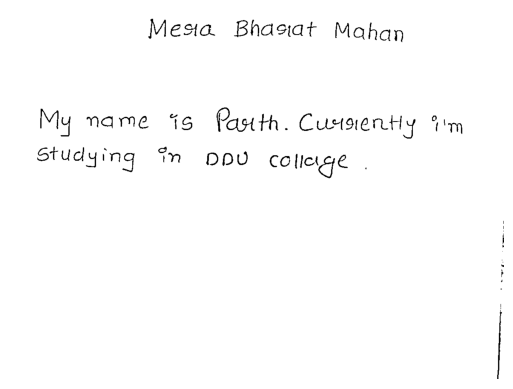

In [58]:
import cv2
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

# Load image
image = Image.open("i5.jpeg").convert("RGB")

img = convert_image_to_black_and_white(image)


# Show black & white image
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()


In [51]:
lines = split_bw_image_into_valid_lines(bw)

print("Lines with text:", len(lines))

Lines with text: 3


Lines detected: 3


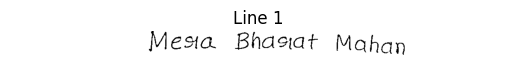

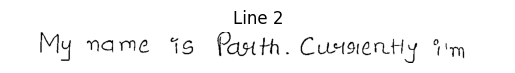

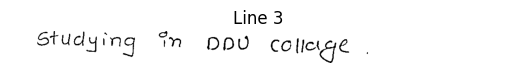

In [54]:
from matplotlib import pyplot as plt


print("Lines detected:", len(lines))

for i, line in enumerate(lines):
    plt.imshow(line, cmap="gray")
    plt.axis("off")
    plt.title(f"Line {i+1}")
    plt.show()
